# 데이터 증강 (Data Augmentation)

데이터 증강은 기존 학습 데이터의 양과 다양성을 인위적으로 늘려  
딥러닝 / 머신러닝 모델의 **과적합(Overfitting)** 을 방지하고,  
**일반화 성능**을 향상시키는 기법입니다.

적은 데이터를 활용해 고품질 학습 데이터셋을 구축할 수 있기 때문에  
데이터 수집 비용을 절감하는 핵심 기술로 사용됩니다.

---

## 1. 핵심 목적 및 효과

### 1.1 과적합 방지

모델이 훈련 데이터에만 너무 맞춰지는 것을 막고,  
새로운 데이터에 대해서도 안정적으로 예측할 수 있도록 도와줍니다.

이를 통해 모델의 **강건성(Robustness)** 이 향상됩니다.



### 1.2 데이터 부족 해결

데이터를 충분히 확보하기 어려운 분야에서 유용하게 사용됩니다.

예를 들어, 희귀 질환 의료 영상 분석처럼  
학습 데이터가 부족한 경우 데이터 증강을 통해  
데이터의 양과 다양성을 늘릴 수 있습니다.

또한 클래스 간 데이터 수가 크게 차이 나는  
**데이터 불균형 문제**를 완화하는 데도 도움이 됩니다.



### 1.3 성능 향상

다양한 형태로 변형된 데이터를 학습함으로써  
모델이 데이터의 본질적인 특징을 더 잘 학습할 수 있습니다.

결과적으로 모델의 전체적인 정확도와 일반화 성능을 높이는 데 기여합니다.

---

## 2. 주요 데이터 증강 기법

---

## 2.1 이미지(Image) 데이터 증강

이미지 데이터에서는 원본 이미지를 다양한 방식으로 변형하여  
새로운 학습 데이터처럼 사용합니다.

### 반전(Flipping)

이미지를 수평 또는 수직 방향으로 뒤집는 방법입니다.

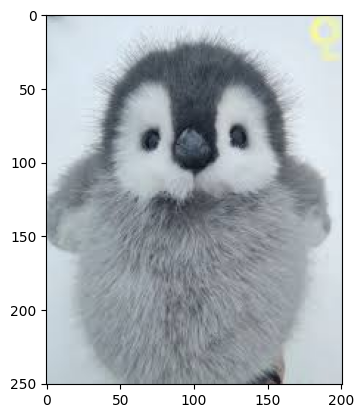

In [2]:
# pip install opencv-python <= colab은 이미 설치됨

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image = cv2.cvtColor(cv2.imread('test_aug.jpeg'), cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

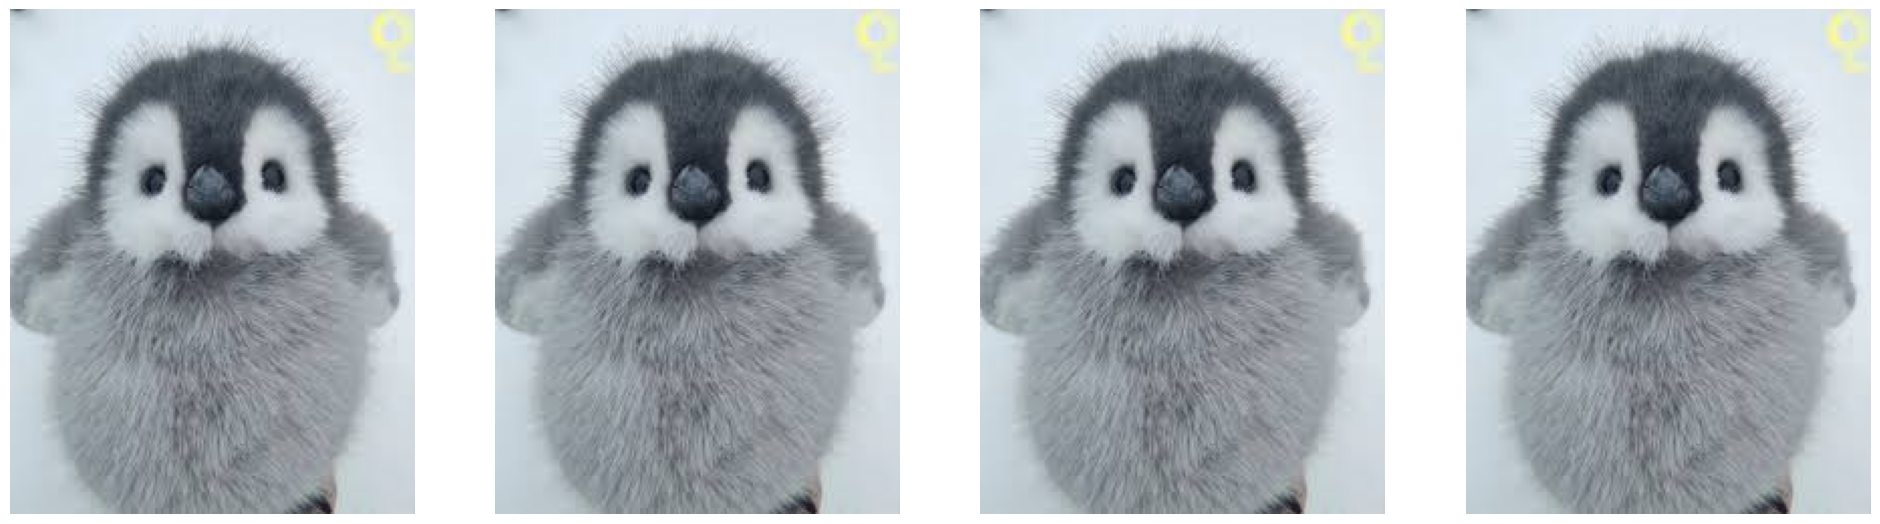

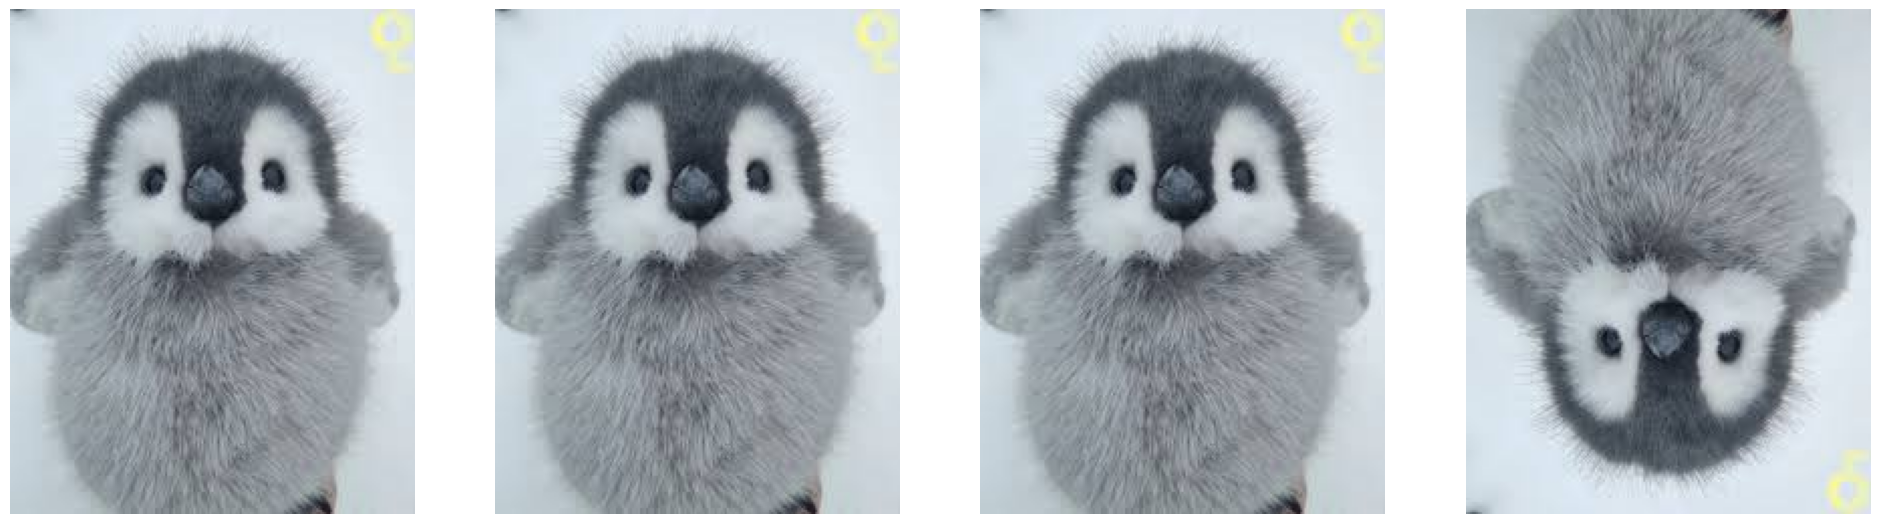

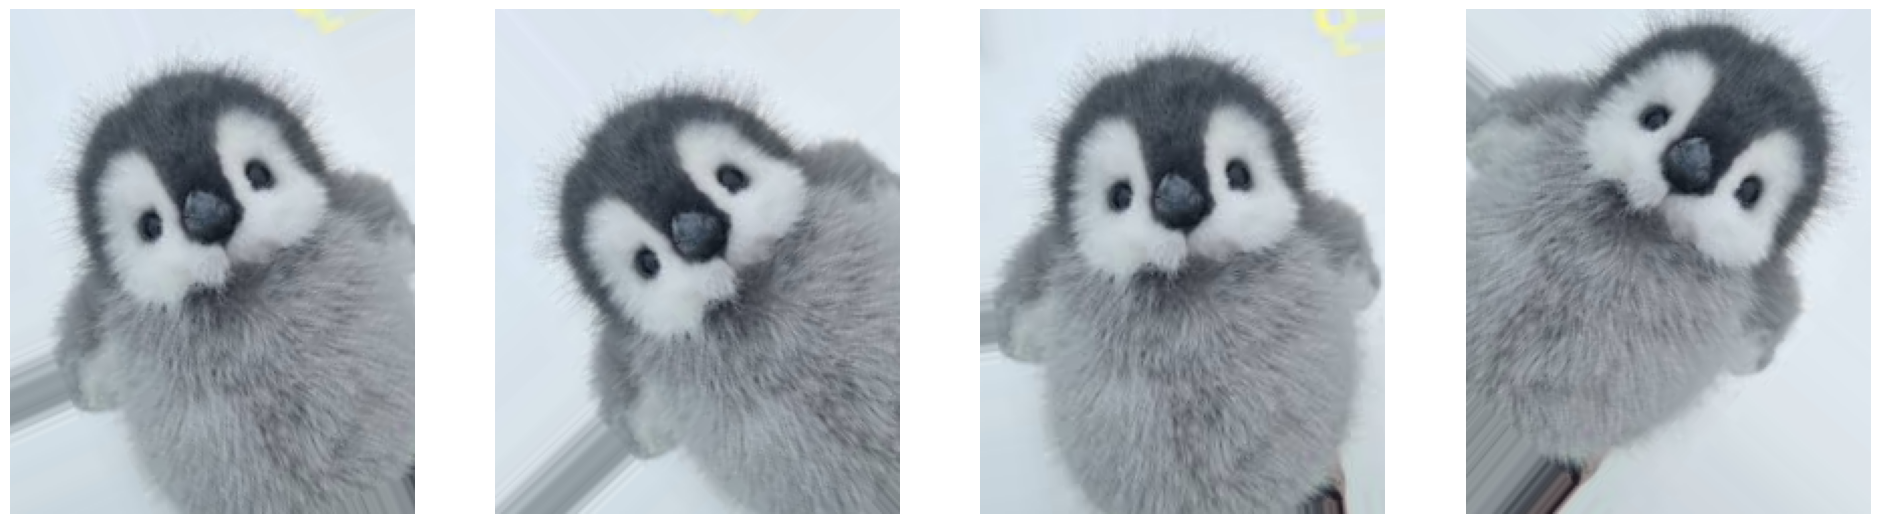

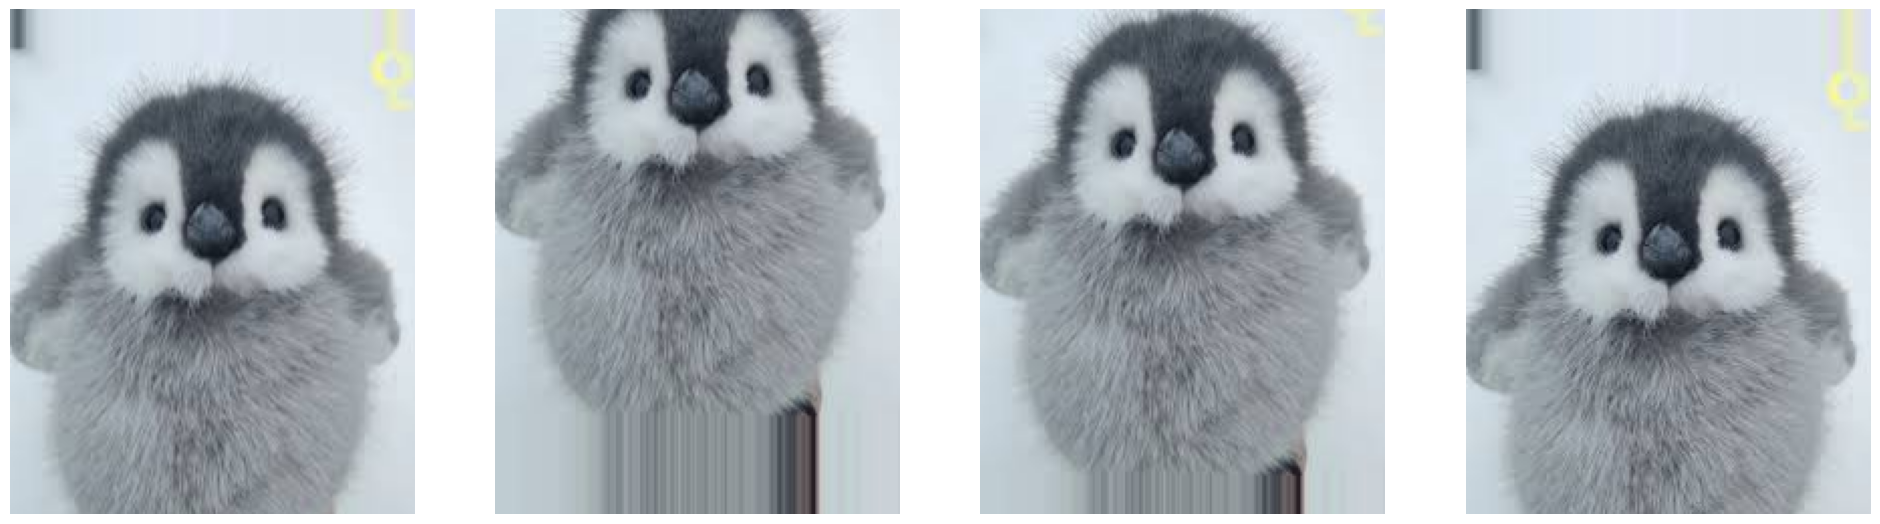

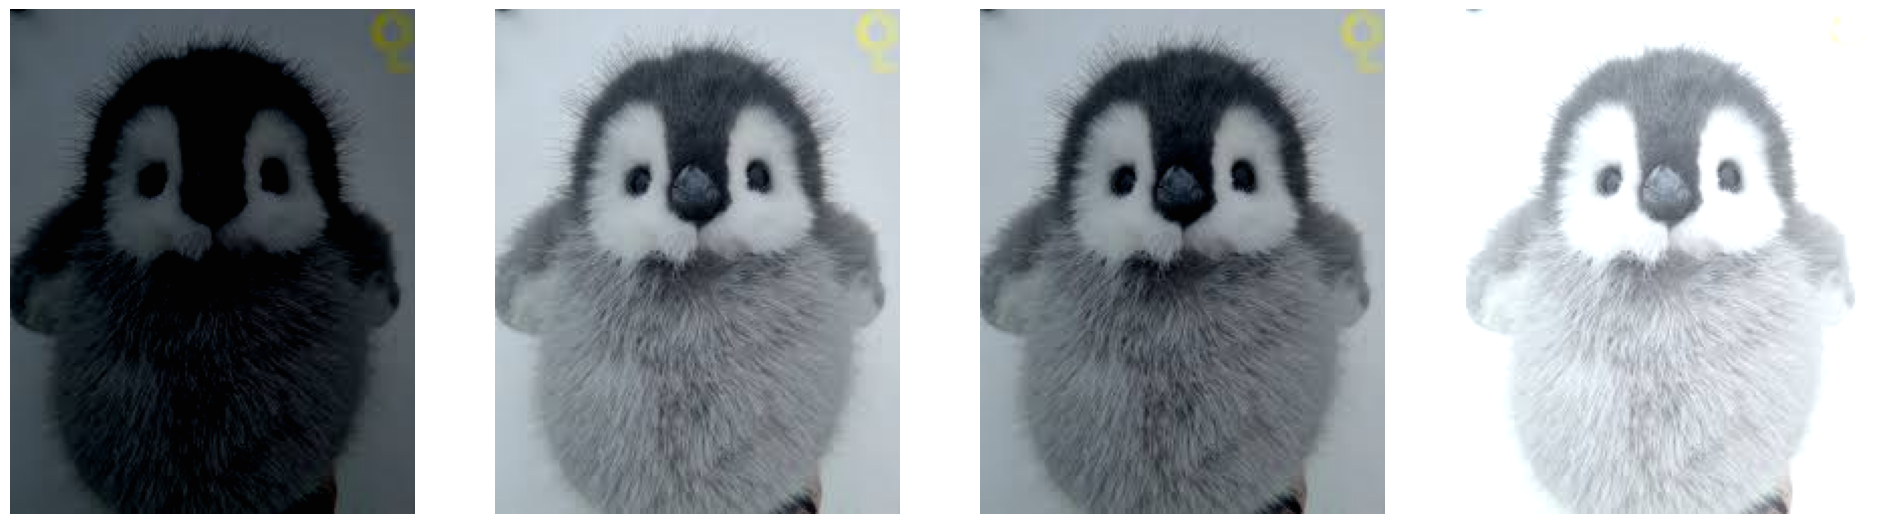

In [11]:
def show_aug_func(image, generator, n_images=4):
  image_batch = np.expand_dims(image, axis=0) # 차원 확장
  generator.fit(image_batch)

  # 메모리에 로딩된 이미지 배열을 ImageDataGenerator에 넣어서 증강된 이미지를 배치단위로 생성.
  data_gen_iter = generator.flow(image_batch)
  fig, axs = plt.subplots(nrows=1, ncols=n_images, figsize=(24, 8))

  for i in range(n_images):

    # next : generator.flow(image_batch) 이미지 배치에 있는 이미지를 하나씩 꺼내볼 때 사용
    aug_image_batch = next(data_gen_iter)

    # 차원 축소 - 크기가 1인 축 제거해 차원 축소
    # ex) [[[1, 2, 3]]] -> [1, 2, 3]
    aug_image = np.squeeze(aug_image_batch)

    aug_image = aug_image.astype('int')

    # 이미지 출력
    axs[i].imshow(aug_image)
    axs[i].axis('off')
  plt.show()

# horizontal_flip 좌우 반전
data_generator = ImageDataGenerator(horizontal_flip=True)
show_aug_func(image, data_generator, n_images=4)

# vertical_flip 상하 반전
data_generator = ImageDataGenerator(vertical_flip=True)
show_aug_func(image, data_generator, n_images=4)

# rotation_range 회전
data_generator = ImageDataGenerator(rotation_range=45)
show_aug_func(image, data_generator, n_images=4)

# width_shift_range 좌우로 랜덤하게 이동
data_generator = ImageDataGenerator(width_shift_range=0.3, fill_mode='nearest')
show_aug_func(image, data_generator, n_images=4)

# channel_shift_range 색상 channel값 랜덤하게 변경
data_generator = ImageDataGenerator(channel_shift_range=150)
show_aug_func(image, data_generator, n_images=4)

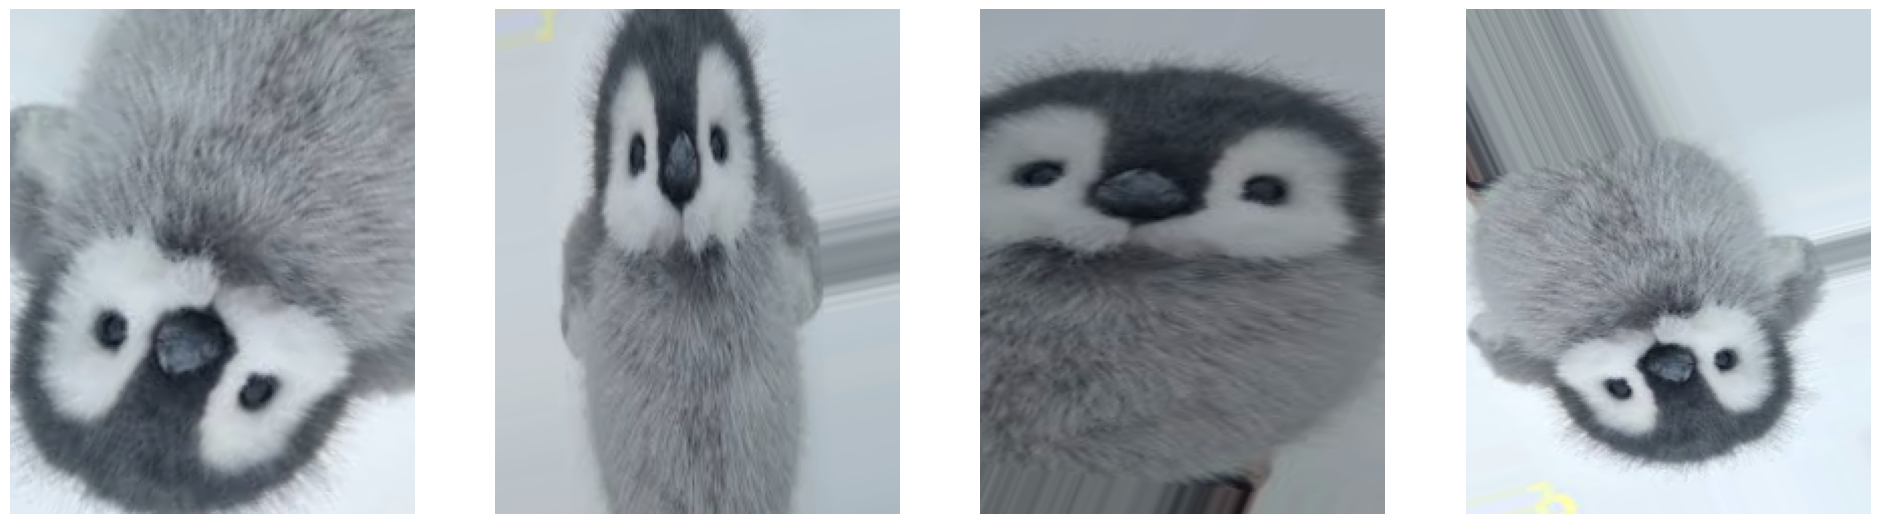

In [12]:
data_gen = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.2,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.5
)

show_aug_func(image, data_gen, n_images=4)